# Advacned Deep Learning - Multimodal Retrieval with CLIP on Flickr8k

Author: Nicolas Vogel
Submission date: 15.12.2025
course: Advanced Deep Learning (AS 2025)

## Sections
0. Introduction
1. Pre-Setting, Imports and Data Loading
2. Data Analysis and Visualization
3. Data Preprocessing
4. Model Building and Training
5. Evaluation
6. Final Remarks

# 0. Introduction
## 0.1 Taks
In this project a multimodal retrieval system is implemented using the CLIP model on the Flickr8k dataset. The goal is to enable retrieval of images based on text queries and vice versa. The project involves data analysis, preprocessing, model fine-tuning, and evaluation of retrieval performance.

In a frist step a pretrained model (ClIP) is finetuned on the Flickr8k dataset. In a second step the model is tested with various text and image queries to evaluate its retrieval capabilities. The performance is measured using metrics such as Recall@K and mean similiarity.


## 0.2 Related Work and References
### CLIP
CLIP was

Learning Transferable Visual Models From Natural Language Supervision





The underlying model used in this project is CLIP (Contrastive Language-Image Pretraining) developed by OpenAI. CLIP is a powerful multimodal model that learns to associate images and text by training on a large dataset of image-caption pairs. The model uses a contrastive learning approach to align visual and textual representations in a shared embedding space. it is trained on a diverse dataset of 400 million image-text pairs collected from the internet. This extensive training allows CLIP to generalize well to various downstream tasks, including image classification, object detection, and multimodal retrieval [1].

### Flickr8k Dataset
The dataset contains 8,000 images collected from Flickr, each paired with five different captions. The images cover a wide range of scenes and objects, especially outdoor activities, people, and animals as later can be seen in the analysis of the dataset. The captions are human-generated and provide descriptive information about the content of the images [2].







[1] C. Lülf, D. M. L. Martins, M. A. V. Salles, Y. Zhou, und F. Gieseke, „CLIP-Branches: Interactive Fine-Tuning for Text-Image Retrieval“, 19. Juni 2024, arXiv: arXiv:2406.13322. doi: 10.48550/arXiv.2406.13322.

[2] https://github.com/Avaneesh40585/Flickr8k-Dataset


## 0.3 Sumbission Data






# 1     Pre-Setting, Imports and Data Loading
In this section the necessary modules are imported, paths are set up, and the Flickr8k dataset is loaded for further processing. Also some helper functions are defined to facilitate model saving and project structure management.

## 1.1 Modules and helper functions

In [51]:
# ======================= Module Imports ============================= #

# ========== Base Modules
from datetime import datetime
import time

import numpy as np
from pathlib import Path
import os
import pandas as pd # for data handling

# ========== Modules for Data Analysis and handling
import re # for regex operations to analyze captions
from collections import Counter # to count word frequencies
from sklearn.model_selection import train_test_split # for splitting dataset
import itertools

# ========== Deep Learning Modules
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from tqdm import tqdm

# ========== Models
from transformers import CLIPProcessor, CLIPModel

# ========== Custom Module for dataloader
import importlib
import my_dataset
importlib.reload(my_dataset)
from my_dataset import Flickr8kDataset
import utils
importlib.reload(utils)
from utils import *

# ========== Visualization Modules
from PIL import Image # for image processing
import matplotlib.pyplot as plt # for visualization


In [52]:
# ================== Helperfunctions ======================== #

# ========= find project root
def find_project_root(start: Path = Path.cwd()):
    """Find the project root directory by looking for common markers."""
    # look for common project markers and return the first match
    for p in [start] + list(start.parents):
        if (p / 'data').exists() or (p / '.git').exists() or (p / 'pyproject.toml').exists():
            return p.resolve()
    return Path.cwd().resolve()

# ========== compile model filename
def compile_filename(subset_size, device, batch, epochs, lr, description):
    today = datetime.now().strftime("%Y%m%d")
    file_name = f"{today}_clip_{device}_sub-size{subset_size}_bs{batch}_ep{epochs}_lr{lr}_{description}"
    return file_name



## 1.2 Funcitonality Pre-settings
Here paths and flags are set for data loading, model saving, and training configurations.

In [53]:
# ===================== Path Settings ========================= #

# ============= set project root
try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    # fallback for Jupyter notebooks
    PROJECT_ROOT = find_project_root()

# ============= PROJECT_ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data"
IMG_DIR = DATA_DIR / "Images"
CAPTIONS_FILE = DATA_DIR / "flickr8k_captions.csv"
RUNS_DIR = PROJECT_ROOT / "runs"


In [54]:
# ==================== Flags ======================= #

# ========= Finetuning flag
finetuning = True

# ========= model saving flag
save_model = True

# ========= DataLoader and subset parameters
use_subset = False
subset_size = "-full"  # Number of samples in subset
batch_size = 32 # for DataLoader
num_workers = 0  # for DataLoader # 0 for local; 4 for cluster


# ========= Plotting parameters
save_plot = True
show_plot = True

# ======== Hyperparameter tuning
hyperparameter_tuning = True


## 1.3 Data Loading


In [55]:
# ================== Load Dataset ====================== #
# =========== load csv file with captions
captions = pd.read_csv(CAPTIONS_FILE, sep=";", engine="python")

# =========== length of dataset
dataset_length = len(captions)
print(f"Dataset contains {dataset_length} image-caption pairs.")

# =========== show first 5 entries
captions.head()


Dataset contains 40455 image-caption pairs.


,filename,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


# 2 Data Analysis and Visualization
In this section the Flickr8k dataset is analyzed and visualized to gain insights into its structure and content. Various statistics about the images and captions are computed and visualized using plots.

## 2.1 Examples

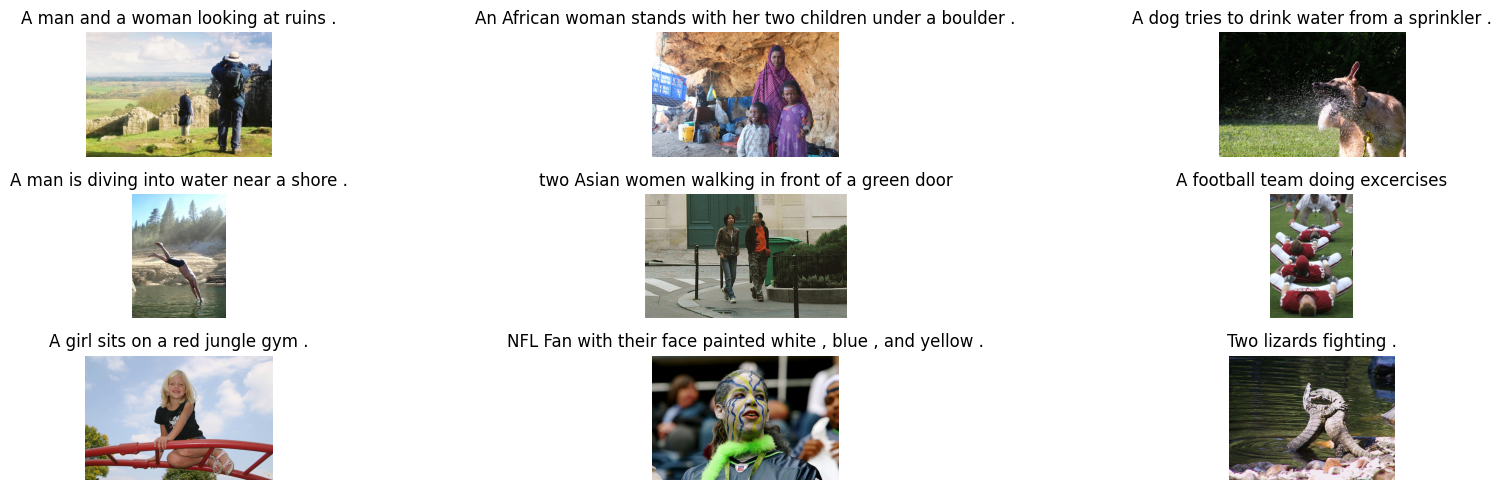

In [56]:
# plot some random images with captions as example
fig, axes = plt.subplots(3, 3, figsize=(20, 5))

# random seed
# np.random.seed(42)

# plot random samples
for ax in axes.ravel():
    row = captions.sample(1).iloc[0]
    img = Image.open(os.path.join(IMG_DIR, row['filename']))
    ax.imshow(img)
    ax.set_title(row['caption'])
    ax.axis('off')

plt.tight_layout()
plt.show()


## 2.2 Image and Caption analysis

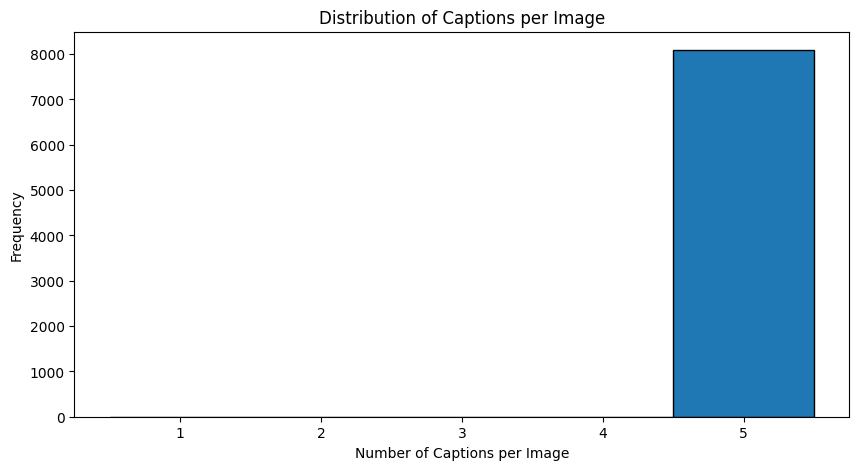

In [57]:
# captions per image

captions_per_image = captions.groupby("filename").size()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(captions_per_image, bins=range(1, captions_per_image.max()+
2), align='left', edgecolor='black')
ax.set_xlabel("Number of Captions per Image")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Captions per Image")
plt.xticks(range(1, captions_per_image.max()+1))
plt.show()



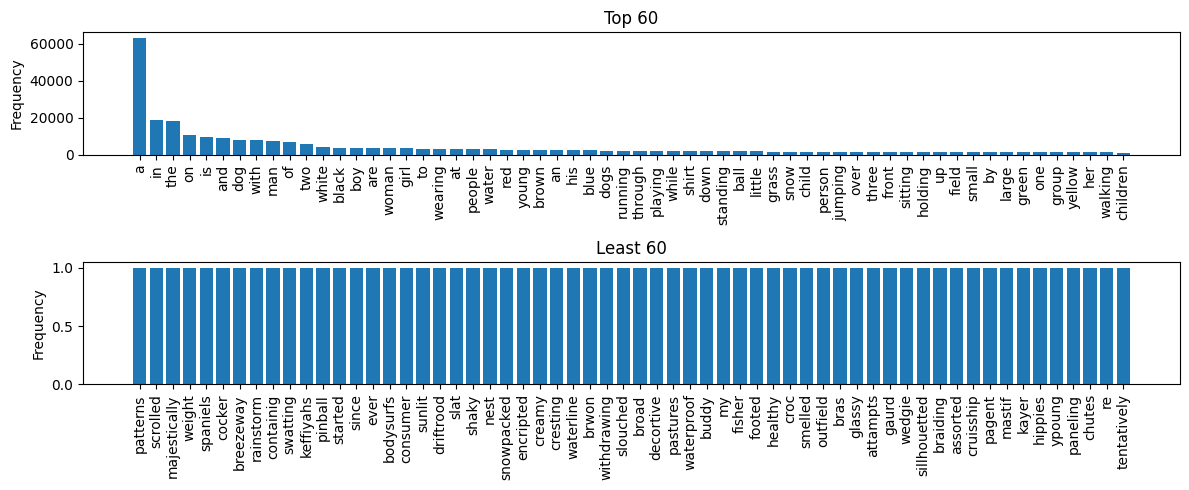

In [58]:
# combine all captions into one large text
text = " ".join(captions["caption"].astype(str)).lower()

# extract words using regex
words = re.findall(r"\b\w+\b", text)

# count word frequencies
freq = Counter(words)

# get the 30 most common and 30 least common words
top30 = freq.most_common(60)
least30 = freq.most_common()[:-61:-1]

# print(top30)

# Plot the results
fig, axes = plt.subplots(2, 1, figsize=(12, 5))

# top: Top 30
axes[0].bar([w for w,_ in top30], [c for _,c in top30])
axes[0].set_title("Top 60")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis='x', rotation=90)

# bottom: Least 30
axes[1].bar([w for w,_ in least30], [c for _,c in least30])
axes[1].set_title("Least 60")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

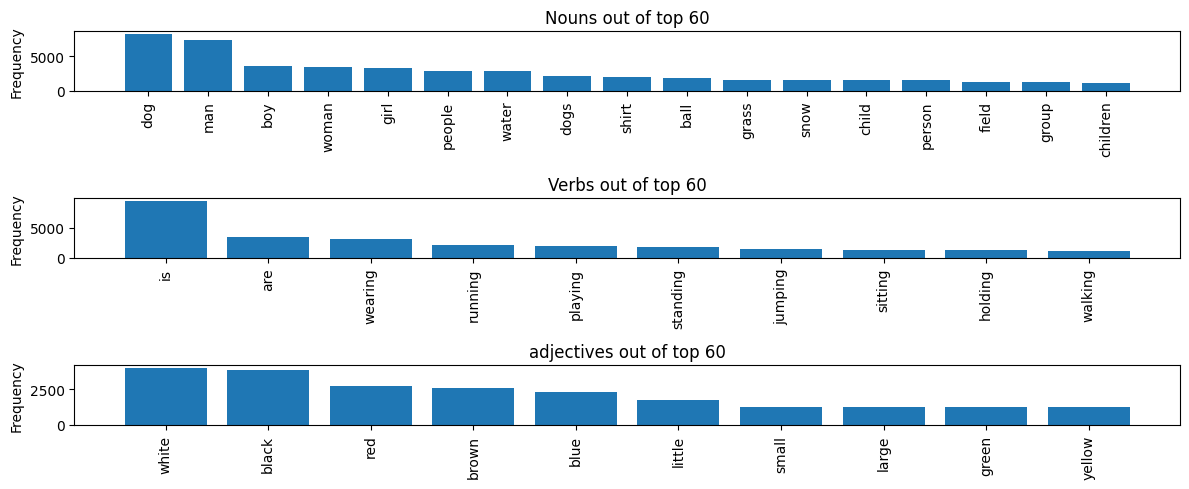

In [59]:
# closer look at nouns, verbs, adjectives in top 60 words
# manually categorized based on common English usage

# top 60 words categorized
top60_nouns = [('dog', 8138), ('man', 7274), ('boy', 3581), ('woman', 3402), ('girl', 3328), ('people', 2883), ('water', 2790), ('dogs', 2125), ('shirt', 1962), ('ball', 1783), ('grass', 1622), ('snow', 1547), ('child', 1545), ('person', 1542), ('field', 1283), ('group', 1218), ('children', 1156)]

top60_verbs = [('is', 9345), ('are', 3504), ('wearing', 3062), ('running', 2073), ('playing', 2008), ('standing', 1787), ('jumping', 1473), ('sitting', 1368), ('holding', 1324), ('walking', 1165)]

top60_adj = [('white', 3959), ('black', 3848), ('red', 2691), ('brown', 2578), ('blue', 2279), ('little', 1768), ('small', 1278), ('large', 1236), ('green', 1234), ('yellow', 1217)]

# Plot the results
fig, axes = plt.subplots(3, 1, figsize=(12, 5))

# top: Top 30
axes[0].bar([w for w,_ in top60_nouns], [c for _,c in top60_nouns])
axes[0].set_title("Nouns out of top 60")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis='x', rotation=90)

# bottom: Least 30
axes[1].bar([w for w,_ in top60_verbs], [c for _,c in top60_verbs])
axes[1].set_title("Verbs out of top 60")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis='x', rotation=90)

# bottom: Least 30
axes[2].bar([w for w,_ in top60_adj], [c for _,c in top60_adj])
axes[2].set_title("adjectives out of top 60")
axes[2].set_ylabel("Frequency")
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [60]:
# number of unique words
num_unique_words = len(freq)
print(f"Number of unique words in captions: {num_unique_words}")

Number of unique words in captions: 8488


In [61]:
# average caption length
avg_caption_length = sum(len(caption.split()) for caption in captions["caption"]) / dataset_length
print(f"Average caption length: {avg_caption_length:.2f} words")


Average caption length: 11.78 words


Average image size: 397.25 x 457.87 pixels


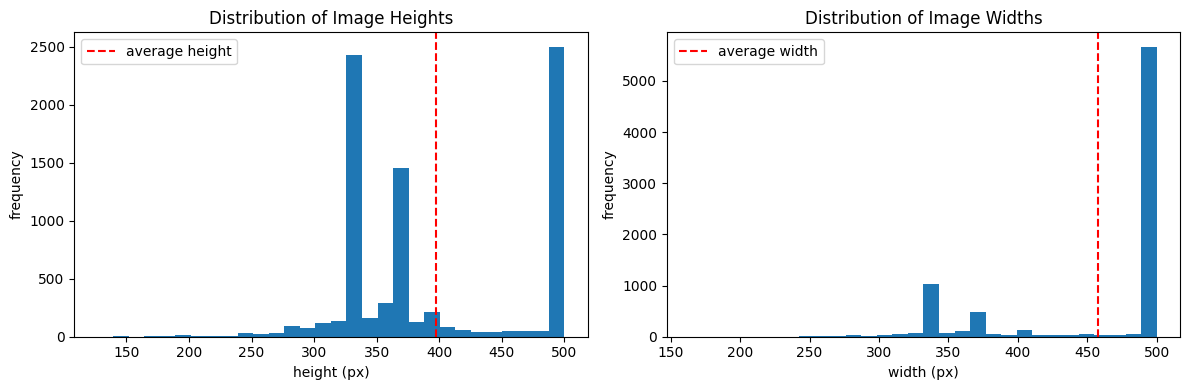

In [62]:
# image proerties
image_sizes = []
for filename in captions["filename"].unique():
    img_path = os.path.join(IMG_DIR, filename)
    with Image.open(img_path) as img:
        image_sizes.append(img.size)
widths, heights = zip(*image_sizes)
avg_width = sum(widths) / len(widths)
avg_height = sum(heights) / len(heights)
print(f"Average image size: {avg_height:.2f} x {avg_width:.2f} pixels")


fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(heights, bins=30)
ax[0].axvline(avg_height, linestyle="--", color = 'red')
ax[0].set_xlabel("height (px)")
ax[0].set_ylabel("frequency")
ax[0].set_title("Distribution of Image Heights")
ax[0].legend(["average height"])

ax[1].hist(widths, bins=30)
ax[1].axvline(avg_width, linestyle="--", color = 'red')
ax[1].set_xlabel("width (px)")
ax[1].set_ylabel("frequency")
ax[1].set_title("Distribution of Image Widths")
ax[1].legend(["average width"])

plt.tight_layout()
plt.show()


# 3 Data Preprocessing

## 3.1 Subset

In [63]:
# subset option
if use_subset:
    unique_images = captions['filename'].unique() # get unique image filenames
    chosen = pd.Series(unique_images).sample(n=subset_size, random_state=42) # randomly choose a subset
    subset = captions[captions['filename'].isin(chosen)].reset_index(drop=True)# filter captions to only include chosen images
    captions = subset.copy()  # update captions to only include subset

# print dataset info
print(captions["filename"].nunique(), "images in dataset")  # number of unique images in subset
print(captions.groupby("filename").size().describe())# number of captions per image in subset
# captions.head() # display first few entries of subset

8091 images in dataset
count    8091.0
mean        5.0
std         0.0
min         5.0
25%         5.0
50%         5.0
75%         5.0
max         5.0
dtype: float64


## 3.2 Dataloader

In [64]:
# create new csv file for subset
date = datetime.now().strftime("%Y%m%d")
subset_captions_file = DATA_DIR / f"{date}_flickr8k_captions_subset_{subset_size}imgs.csv"
captions.to_csv(subset_captions_file, sep=";", index=False)
CAPTIONS_FILE = subset_captions_file

# get unique images for proper splitting
images = captions["filename"].unique()

# split into train, val, test
train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)
val_imgs, test_imgs = train_test_split(test_imgs, test_size=0.5, random_state=42)

# filter captions dataframe based on image splits
train_df = captions[captions["filename"].isin(train_imgs)]
val_df   = captions[captions["filename"].isin(val_imgs)]
test_df  = captions[captions["filename"].isin(test_imgs)]


# create datasets
train_dataset = Flickr8kDataset(str(IMG_DIR), train_df)
val_dataset   = Flickr8kDataset(str(IMG_DIR), val_df)
test_dataset  = Flickr8kDataset(str(IMG_DIR), test_df)

# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)



# 4 Model Building and Training

## 4.1 Loading Pretrained Model

In [65]:
# load pretrained CLIP model and processor
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

# freez model parameters
for param in model.parameters():
    param.requires_grad = False

# onyl train projection layers
for param in model.visual_projection.parameters():
    param.requires_grad = True
for param in model.text_projection.parameters():
    param.requires_grad = True

# optimizer, loss function and other parameters
loss_fn = nn.CrossEntropyLoss()
epochs = 30
lr = 5e-5
batch_size = batch_size

if finetuning:
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
else:
    optimizer = optim.AdamW(model.text_model.parameters(), lr=lr)


# move model to device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(DEVICE)
model.train()

# prepare filename for saving
run_name = "test-run"
filename = compile_filename(subset_size, DEVICE, batch_size, epochs, lr, run_name)
print(f"Model will be saved as: {filename}")



Model will be saved as: 20251120_clip_cpu_sub-size-full_bs32_ep30_lr5e-05_test-run



## 4.2 Training Loop

In [66]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, filename, patience=5):

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    logs = []

    # ---------- METRIC FUNCTION ----------
    def compute_metrics(model, processor, dataloader):
        model.eval()
        all_image_embs = []
        all_text_embs = []

        with torch.no_grad():
            for images, texts in dataloader:
                inputs = processor(text=texts, images=images, return_tensors="pt", padding=True).to(DEVICE)

                img = model.get_image_features(pixel_values=inputs["pixel_values"])
                txt = model.get_text_features(input_ids=inputs["input_ids"],
                                              attention_mask=inputs["attention_mask"])

                img = img / img.norm(dim=-1, keepdim=True)
                txt = txt / txt.norm(dim=-1, keepdim=True)

                all_image_embs.append(img)
                all_text_embs.append(txt)

        all_image_embs = torch.cat(all_image_embs)
        all_text_embs = torch.cat(all_text_embs)

        sims = (all_image_embs * all_text_embs).sum(dim=-1)
        mean_sim = sims.mean().item()

        recall_at_k = {}
        sim_matrix = all_image_embs @ all_text_embs.T

        for k in [1, 5, 10]:
            topk = sim_matrix.topk(k, dim=1).indices
            correct = sum(i in topk[i] for i in range(len(all_image_embs)))
            recall_at_k[f"recall@{k}"] = correct / len(all_image_embs)

        return mean_sim, recall_at_k

    # ------------------ TRAINING LOOP -------------------
    for epoch in range(num_epochs):
        start = time.time()

        # ----- TRAIN -----
        model.train()
        train_loss = 0

        for images, texts in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
            inputs = processor(images=images, text=texts, padding=True, return_tensors="pt").to(DEVICE)
            outputs = model(**inputs)

            logits_i = outputs.logits_per_image
            logits_t = outputs.logits_per_text

            gt = torch.arange(len(images), device=DEVICE)
            loss = (criterion(logits_i, gt) + criterion(logits_t, gt)) / 2

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ----- VALIDATION -----
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, texts in val_loader:
                inputs = processor(images=images, text=texts, padding=True, return_tensors="pt").to(DEVICE)
                outputs = model(**inputs)

                logits_i = outputs.logits_per_image
                logits_t = outputs.logits_per_text

                gt = torch.arange(len(images), device=DEVICE)
                loss = (criterion(logits_i, gt) + criterion(logits_t, gt)) / 2

                val_loss += loss.item()

        val_loss /= len(val_loader)

        # -------- METRICS AFTER EACH EPOCH --------
        mean_sim, rec = compute_metrics(model, processor, val_loader)

        logs.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "mean_similarity": mean_sim,
            "recall@1": rec["recall@1"],
            "recall@5": rec["recall@5"],
            "recall@10": rec["recall@10"],
            "time_sec": time.time() - start
        })

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"MeanSim: {mean_sim:.4f} | "
            f"R@1: {rec['recall@1']:.3f} | "
            f"Epoch time: {time.time() - start:.2f}s"
        )

        # -------- EARLY STOPPING --------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # restore best model
    model.load_state_dict(best_model_state)

    # save model
    if save_model:
        save_path = RUNS_DIR / filename
        save_path.mkdir(parents=True, exist_ok=True)
        model_file = save_path / f"{filename}_model.pth"
        torch.save(model.state_dict(), model_file)
        print(f"Model saved to {model_file}")

    return pd.DataFrame(logs)


In [67]:
# train model
if not hyperparameter_tuning:
    logs = train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs, filename, patience=5)

## 4.3 Saving the Model and export Data

In [68]:
# save logs to csv
if not hyperparameter_tuning:
    if save_model:
        model_file = RUNS_DIR / filename / f"{filename}_logs.csv"
        logs.to_csv(model_file, index=False)
        print(f"Training logs saved to {model_file}")


In [69]:
# plot training results
if not hyperparameter_tuning:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(logs["epoch"], logs["train_loss"], label="Train Loss")
    ax.plot(logs["epoch"], logs["val_loss"], label="Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Training and Validation Loss over Epochs - {run_name}")
    ax.legend()
    if save_plot:
        plot_file = RUNS_DIR / filename / f"{filename}_loss-plot.png"
        plt.savefig(plot_file)
    if show_plot:
        plt.show()

In [70]:
# plot recalls
if not hyperparameter_tuning:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(logs["epoch"], logs["recall@1"], label="Recall@1")
    ax.plot(logs["epoch"], logs["recall@5"], label="Recall@5")
    ax.plot(logs["epoch"], logs["recall@10"], label="Recall@10")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Recall")
    ax.set_title(f"Recall over Epochs - {run_name}")
    ax.legend()
    if save_plot:
        plot_file = RUNS_DIR / filename / f"{filename}_recall-plot.png"
        plt.savefig(plot_file)
    if show_plot:
        plt.show()


## 4.3 Hyperparameter Tuning


In [71]:
if hyperparameter_tuning:
    best_model = None
    best_performance = 0
    best_hyperparams = {}

    # Grid
    hyperparameter_grid = {
        "learning_rate": [1e-5, 5e-5, 1e-4],
        "batch_size": [16, 32, 64],
        "num_epochs": [30]
    }
    # Number of Hyperparameter combinations
    total_runs = (len(hyperparameter_grid["learning_rate"]) *
          len(hyperparameter_grid["batch_size"]) *
          len(hyperparameter_grid["num_epochs"])
    )
    current_run = 1
    print(f"Total Hyperparameter combinations to try: {total_runs}")



    for lr, batch_size, epochs in itertools.product(
        hyperparameter_grid["learning_rate"],
        hyperparameter_grid["batch_size"],
        hyperparameter_grid["num_epochs"]
    ):
        today = datetime.now().strftime("%Y%m%d")
        run_name = f"{today}_HT_lr{lr}_bs{batch_size}_ep{epochs}"
        run_dir = RUNS_DIR / run_name
        run_dir.mkdir(parents=True, exist_ok=True)

        print(f"\n=== Training {run_name} | run {current_run}/{total_runs} ===")

        # ----- Reinitialize model + optimizer -----
        model = CLIPModel.from_pretrained(model_name)

        # freez parameters
        for param in model.parameters():
            param.requires_grad = False

        # only train projection layers
        for param in model.visual_projection.parameters():
            param.requires_grad = True
        for param in model.text_projection.parameters():
            param.requires_grad = True


        # Optimizer
        optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

        # data loader with new batch size
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

        model.to(DEVICE)

        # ----- Train -----
        logs = train_model(
            model,
            train_loader,
            val_loader,
            loss_fn,
            optimizer,
            epochs,
            filename=run_name,
            patience=3)

        # ----- Save logs -----
        logs_file = run_dir / f"{run_name}_logs.csv"
        logs.to_csv(logs_file, index=False)
        print(f"Logs saved: {run_name}_logs.csv")

        # ----- Save model -----
        model_file = run_dir / f"{run_name}_model.pth"
        torch.save(model.state_dict(), model_file)
        print(f"Model saved: {run_name}_model.pth")

        # ----- LOSS Plot -----
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(logs["epoch"], logs["train_loss"], label="Train Loss")
        ax.plot(logs["epoch"], logs["val_loss"], label="Val Loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(f"Loss - {run_name}")
        ax.legend()
        plt.savefig(run_dir / f"{run_name}_loss_plot.png")
        plt.close()
        print(f"Loss-Plot saved")

        # ----- RECALL Plot -----
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(logs["epoch"], logs["recall@1"],  label="Recall@1")
        ax.plot(logs["epoch"], logs["recall@5"],  label="Recall@5")
        ax.plot(logs["epoch"], logs["recall@10"], label="Recall@10")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Recall")
        ax.set_title(f"Recalls - {run_name}")
        ax.legend()
        plt.savefig(run_dir / f"{run_name}_recall_plot.png")
        plt.close()
        print(f"Recall-Plot saved")

        # ----- Evaluate performance -----
        final_recall = logs["recall@1"].iloc[-1]

        if final_recall > best_performance:
            best_performance = final_recall
            best_model = model.state_dict()
            best_hyperparams = {
                "learning_rate": lr,
                "batch_size": batch_size,
                "num_epochs": epochs
            }
        current_run += 1

    # ---------- SUMMARY ----------
    print("\n====================")
    print("   BEST RUN")
    print("====================")
    print(best_hyperparams)
    print(f"Best Recall@1: {best_performance:.4f}")


Total Hyperparameter combinations to try: 9

=== Training 20251120_HT_lr1e-05_bs16_ep30 | run 1/9 ===


KeyboardInterrupt: 

# 5 Evaluation

# 6 Final Remarks